In [1]:
# https://docs.opencv.org/3.4/d4/d61/tutorial_warp_affine.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html#scipy.stats.rv_discrete
# https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html
# https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html
# https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html

In [2]:
# import os
# import sys
# import time
import logging
import numpy as np
from scipy import stats
from scipy import fft
import matplotlib.pyplot as plt
import pyvista as pv
# import cv2 as cv
# import vtk
import glob
import skimage as ski
import pywt
# from pathlib import Path

In [3]:
# fileLogOut = logging.FileHandler("rockProcessing.log", mode = 'w')
# consoleLogOut = logging.StreamHandler()
# logging.basicConfig(handlers = (fileLogOut, consoleLogOut), level = logging.INFO)
logging.basicConfig(filename="rockProcessing.log", level = logging.INFO)
logger = logging.getLogger('logger')

In [4]:
# Get slices:
CTSources = glob.glob("block_5/im6_shared/" + "im_*[0-9].jp2")

In [5]:
# Sort slices
CTSources = sorted(CTSources)

In [6]:
# Reading images and moments calculation
CTImages = []
imagesMoments = []

for i in np.arange(0, len(CTSources), dtype = np.int64):
    CTImages.append(ski.io.imread(CTSources[i]))
    # CTImages.append(
    #     cv.imread(
    #         str(CTSources[i]),
    #         cv.IMREAD_GRAYSCALE
    #     )
    # )
    # imagesMoments.append(cv.moments(CTImages[-1]))
    imagesMoments.append(ski.measure.moments(CTImages[-1], order=0))
    logger.info(str(CTSources[i]))
    logger.info('\tHeight: ' + str(CTImages[i].shape[0]))
    logger.info('\tWidth: ' + str(CTImages[i].shape[1]))

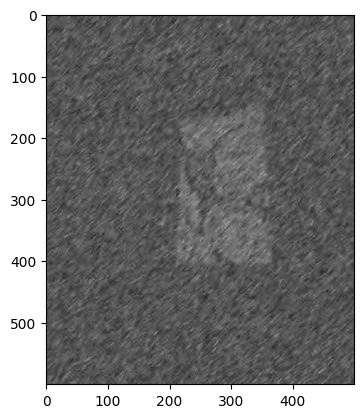

In [7]:
# Debugging
figure, axis = plt.subplots()
axis.imshow(CTImages[200], cmap='gray', vmin=0, vmax=255)

In [9]:
x = np.arange(0, len(CTImages))
# pk = np.array([imageMoment["m00"] for imageMoment in imagesMoments])
p = np.array([imageMoment[0][0] for imageMoment in imagesMoments])
p = p/np.sum(p)

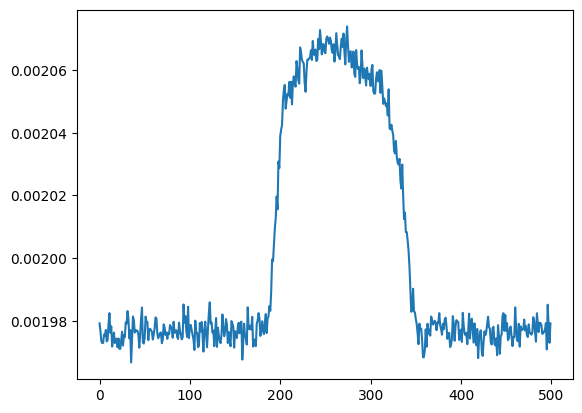

In [10]:
figure, axis = plt.subplots()
axis.plot(x, p)

In [87]:
waveletType="db1"
DWTCoefficients = pywt.wavedec(p, waveletType, mode="symmetric", level=4)

In [88]:
threshold = 1e-3
thresholdedDWTCoeffs = [pywt.threshold(coefficient, threshold, mode='soft') for coefficient in DWTCoefficients]

In [89]:
fp = pywt.waverec(thresholdedDWTCoeffs, waveletType, mode='symmetric')

In [90]:
fp = fp - np.min(fp)

In [91]:
fp = fp/np.sum(fp)

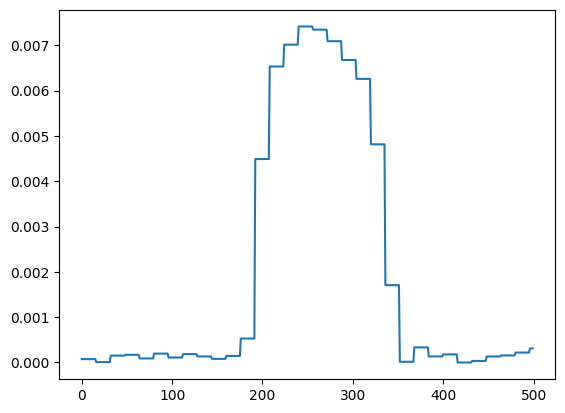

In [92]:
figure, axis = plt.subplots()
axis.plot(x, fp)

In [93]:
customDistribution =\
    stats.rv_discrete(
        name='customDistribution',
        values=(x, fp)
    )

In [94]:
customDistribution.interval(0.95)

(np.float64(182.0), np.float64(349.0))

In [ ]:
# (T, thresholdedCTImage) =\
#     cv.threshold(
#         CTImages[200],
#         100,
#         255,
#         #cv.THRESH_BINARY
#         #Binary Threshold
#         #if src(x,y) > threshold
#             #dst(x,y) = maxValue
#         #else
#             #dst(x,y) = 0
    
#         #cv.THRESH_BINARY_INV
#         #Inverse Binary Threshold
#         #if src(x,y) > threshold
#             #dst(x,y) = 0
#         #else
#             #dst(x,y) = maxValue
    
#         #cv.THRESH_TRUNC
#         #Truncate Threshold
#         #if src(x,y) > threshold
#             #dst(x,y) = threshold
#         #else
#             #dst(x,y) = src(x,y)
    
#         #cv.THRESH_TOZERO
#         #Threshold to Zero
#         #if src(x,y) > threshold
#             #dst(x,y) = src(x,y)
#         #else
#             #dst(x,y) = 0
    
#         cv.THRESH_TOZERO_INV
#         #Inverted Threshold to Zero
#         #if src(x,y) > threshold
#             #dst(x,y) = 0
#         #else
#             #dst(x,y) = src(x,y)
#     )

In [ ]:
# plt.imshow(thresholdedCTImage, cmap='gray', vmin=0, vmax=255)
# plt.show()